# Batch Features

## Problem Statement

Scenario: We're a utility company providing energy to New York City. 

Goal: Every day, we want to accurately predict the energy demand for the next three days so that we can optimally plan our resources.

Task: We will look at historic energy demand and create batch features that we can use to predict the future demand.

## Prerequisites

In [6]:

import pandas as pd

## Data

Let's explore our data!

In [19]:
df = pd.read_csv("data/energy_data.csv")
df

,period,subba,subba-name,parent,parent-name,value,value-units
0,2024-03-30T23,ZONJ,New York City,NYIS,New York Independent System Operator,4980,megawatthours
1,2024-03-30T22,ZONJ,New York City,NYIS,New York Independent System Operator,4892,megawatthours
2,2024-03-30T21,ZONJ,New York City,NYIS,New York Independent System Operator,4798,megawatthours
3,2024-03-30T20,ZONJ,New York City,NYIS,New York Independent System Operator,4760,megawatthours
4,2024-03-30T19,ZONJ,New York City,NYIS,New York Independent System Operator,4772,megawatthours
...,...,...,...,...,...,...,...
2154,2024-01-01T04,ZONJ,New York City,NYIS,New York Independent System Operator,4956,megawatthours
2155,2024-01-01T03,ZONJ,New York City,NYIS,New York Independent System Operator,5112,megawatthours
2156,2024-01-01T02,ZONJ,New York City,NYIS,New York Independent System Operator,5257,megawatthours
2157,2024-01-01T01,ZONJ,New York City,NYIS,New York Independent System Operator,5417,megawatthours


In [10]:
import matplotlib as plt

In [22]:

df.index = pd.to_datetime(df.index)
print(type(df.index))
df2 = df.resample('D').sum('value')
df2

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


,value
period,
2024-01-01,116406
2024-01-02,128866
2024-01-03,131883
2024-01-04,131606
2024-01-05,136960
...,...
2024-03-26,125493
2024-03-27,125867
2024-03-28,125577


<Axes: xlabel='period'>

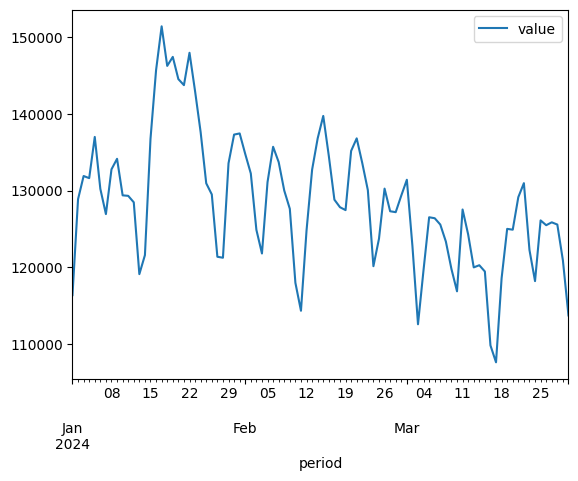

In [24]:
df2.plot()

In [27]:
batchdf = pd.DataFrame()

batchdf['lag1'] = df2['value'].shift(1) # -1 day

batchdf['lag4'] = df2['value'].shift(4) # +3 days - week
batchdf['lag5'] = df2['value'].shift(5) # +2 days - week
batchdf['lag6'] = df2['value'].shift(6) # +1 days - week

batchdf['lag11']= df2['value'].shift(11) # +3 days - 2week
batchdf['lag12']=df2['value'].shift(12) # +2 days - 2week
batchdf['lag13']=df2['value'].shift(13) # +1 days - 2week

batchdf.head()


,lag1,lag4,lag5,lag6,lag11,lag12,lag13
period,,,,,,,
2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-02,116406.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-03,128866.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-04,131883.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-05,131606.0,116406.0,NaN,NaN,NaN,NaN,NaN


In [28]:
batchdf['target1'] = df2['value'].shift(-1)
batchdf['target2'] = df2['value'].shift(-2)
batchdf['target3'] = df2['value'].shift(-3)

In [30]:
batchdf['rolling_mean7'] = df2['value'].rolling(window=7).mean()
batchdf['rolling_std7'] = df2['value'].rolling(window=7).std()

In [32]:
batchdf

,lag1,lag4,lag5,lag6,lag11,lag12,lag13,target1,target2,target3,rolling_mean7,rolling_std7
period,,,,,,,,,,,,
2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128866.0,131883.0,131606.0,NaN,NaN
2024-01-02,116406.0,NaN,NaN,NaN,NaN,NaN,NaN,131883.0,131606.0,136960.0,NaN,NaN
2024-01-03,128866.0,NaN,NaN,NaN,NaN,NaN,NaN,131606.0,136960.0,130213.0,NaN,NaN
2024-01-04,131883.0,NaN,NaN,NaN,NaN,NaN,NaN,136960.0,130213.0,126933.0,NaN,NaN
2024-01-05,131606.0,116406.0,NaN,NaN,NaN,NaN,NaN,130213.0,126933.0,132752.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-26,126118.0,130956.0,129138.0,124910.0,119478.0,120293.0,120013.0,125867.0,125577.0,120926.0,125303.142857,4217.076650
2024-03-27,125493.0,122277.0,130956.0,129138.0,109879.0,119478.0,120293.0,125577.0,120926.0,113774.0,125439.857143,4217.719582
2024-03-28,125867.0,118230.0,122277.0,130956.0,107680.0,109879.0,119478.0,120926.0,113774.0,NaN,124931.142857,3900.127495


In [33]:
batchdf = batchdf.dropna()

In [35]:
corr= batchdf.corr()
corr.style.background_gradient(cmap='coolwarm')

,lag1,lag4,lag5,lag6,lag11,lag12,lag13,target1,target2,target3,rolling_mean7,rolling_std7
lag1,1.000000,0.302505,0.201622,0.197652,0.041389,0.036201,0.150800,0.491790,0.314900,0.231609,0.735396,0.252377
lag4,0.302505,1.000000,0.792653,0.489499,0.389185,0.266067,0.082215,0.214432,0.320147,0.414412,0.791467,-0.091057
lag5,0.201622,0.792653,1.000000,0.798547,0.287637,0.379447,0.238787,0.318708,0.410565,0.302758,0.732367,-0.167635
lag6,0.197652,0.489499,0.798547,1.000000,0.199292,0.304989,0.370801,0.417532,0.315702,0.148122,0.639983,-0.127266
lag11,0.041389,0.389185,0.287637,0.199292,1.000000,0.775969,0.440276,0.139937,0.362888,0.539971,0.263935,0.363765
lag12,0.036201,0.266067,0.379447,0.304989,0.775969,1.000000,0.761331,0.346903,0.500124,0.395421,0.243296,0.270173
lag13,0.150800,0.082215,0.238787,0.370801,0.440276,0.761331,1.000000,0.461421,0.318695,0.117222,0.242832,0.117338
target1,0.491790,0.214432,0.318708,0.417532,0.139937,0.346903,0.461421,1.000000,0.813661,0.546289,0.538036,0.394654
target2,0.314900,0.320147,0.410565,0.315702,0.362888,0.500124,0.318695,0.813661,1.000000,0.815586,0.450516,0.504233
target3,0.231609,0.414412,0.302758,0.148122,0.539971,0.395421,0.117222,0.546289,0.815586,1.000000,0.393690,0.582894


In [37]:
df = pd.read_csv('data/energy_data.csv', parse_dates=['period'])
df.set_index('period', inplace=True)

In [38]:
from scripts import feature_processing
feature_processing.feature_pipeline(df)

,lag_1,lag_4,lag_5,lag_6,lag_11,lag_12,lag_13,rolling_mean_7,rolling_std_7
period,,,,,,,,,
2024-01-14,119134.0,129372.0,134119.0,132752.0,131883.0,128866.0,116406.0,127822.29,5524.62
2024-01-15,121604.0,129308.0,129372.0,134119.0,131606.0,131883.0,128866.0,128386.86,6264.72
2024-01-16,136704.0,128467.0,129308.0,129372.0,136960.0,131606.0,131883.0,130031.00,8953.19
2024-01-17,145628.0,119134.0,128467.0,129308.0,130213.0,136960.0,131606.0,133167.71,12008.71
2024-01-18,151329.0,121604.0,119134.0,128467.0,126933.0,130213.0,136960.0,135579.14,12774.85
...,...,...,...,...,...,...,...,...,...
2024-03-26,126118.0,130956.0,129138.0,124910.0,119478.0,120293.0,120013.0,125303.14,4217.08
2024-03-27,125493.0,122277.0,130956.0,129138.0,109879.0,119478.0,120293.0,125439.86,4217.72
2024-03-28,125867.0,118230.0,122277.0,130956.0,107680.0,109879.0,119478.0,124931.14,3900.13


In [39]:
feature_processing.get_targets(df)

,target_1d,target_2d,target_3d
period,,,
2024-01-01,128866.0,131883.0,131606.0
2024-01-02,131883.0,131606.0,136960.0
2024-01-03,131606.0,136960.0,130213.0
2024-01-04,136960.0,130213.0,126933.0
2024-01-05,130213.0,126933.0,132752.0
...,...,...,...
2024-03-23,118230.0,126118.0,125493.0
2024-03-24,126118.0,125493.0,125867.0
2024-03-25,125493.0,125867.0,125577.0
